# Aplicación de clustering espacialmente restringido 

Se muestra una aplicación de los métodos de clustering espacialmente restringido a los casos de COVID en los departamentos/partidos de Argentina.

## Instalación 

In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Raíz del proyecto añadida al path: {project_root}")
from constantes import *
from datos.scripts_preproceso.lectura_datos_covid import *
import SDEC.regionalizacion as reg
import matplotlib.pyplot as plt
import SDEC.deep_cluster as dc
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


%matplotlib inline
%load_ext autoreload
%autoreload 2



Raíz del proyecto añadida al path: d:\Archivos\Codigos\clustering espacial


## Lectura de datos

In [2]:
covid,geo, centroides, codiprov,covid_acum,personas = df_covid()

d:\Anaconda3\envs\geo\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver ESRI Shapefile does not support open option INDEX
  return ogr_read(


El mes desde el cuál todos los dptos tienen al menos 1 contagiado es: 2021-01


In [3]:
cov = reg.Datos(covid, ['clasificac','fallecido'], 'personas')
df = cov.convertir_a_df(cov.panel_df,['clasificac','fallecido'])
# calculamos la proporcion de cada variable en cada periodo del total de la población
prop = df.iloc[:,:-1].values/df.personas.values.reshape(-1,1)
prop.shape

(525, 34)

In [4]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()
prop_st = st.fit_transform(prop)


In [5]:
geo_prop = gpd.GeoDataFrame(prop_st,columns =  np.array(range(34), str), geometry = geo.reset_index().geometry)
#geo_prop.to_file("SDEC/datos/datos/geo_prop.shp")

In [6]:
km = KMeans(8)
km.fit(prop_st)

d:\Anaconda3\envs\geo\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


KMeans()

In [7]:
km.inertia_

11072.996685875452

In [8]:
import SDEC.sumacuadrados as suc
suc.SSD(prop_st,km.labels_)

[[1. 1.]
 [1. 1.]] 1014616.1127182182 3.1887651055205828e-25 0.03141419063700335


{'TSS': np.float64(19212.678593966702),
 'WSS': np.float64(1408.1759024376292),
 'BSS': np.float64(7947.2713744656685),
 'RBTSS': np.float64(0.41364723485049737)}

In [9]:
suc.SSD(prop,np.random.randint(0,8,525))

{'TSS': np.float64(0.39697426980487677),
 'WSS': np.float64(0.048449365817312906),
 'BSS': np.float64(0.009379343266373519),
 'RBTSS': np.float64(0.023627081097683512)}

## Resultados obtenidos

Se muestran los resultados obtenidos en el paper

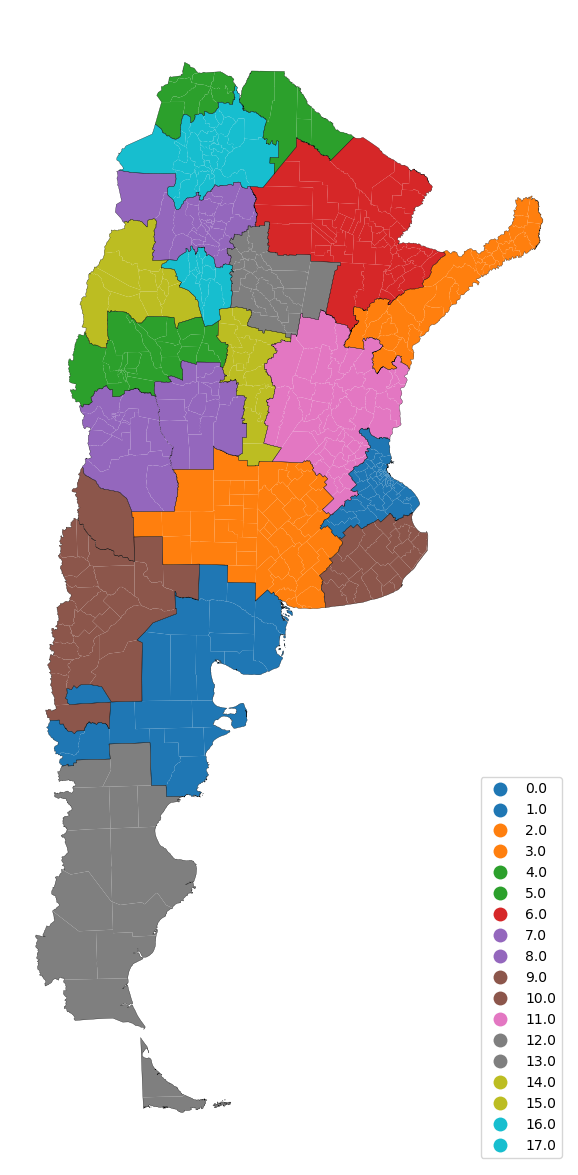

In [38]:
rdos = pd.read_csv(os.path.join(DIR_RESULTADOS, "covid_sdec.csv"))
clusters = rdos.iloc[:,-1]

geo_prop
geos = []

for i in np.unique(clusters):
    g = geo_prop.geometry[clusters == i].union_all()
    geos.append(g)

geos = gpd.GeoSeries(geos)
base = geos.boundary.plot(figsize = (10,15), color = 'black', edgecolor = 'black', linewidth = 0.2)
graf = geo_prop.plot(clusters, figsize = (10,8), categorical = True,legend = True,legend_kwds = {'loc':'lower right'}, ax = base)

graf.set_axis_off()

## Aplicación de spatial deep embeding clustering


In [ ]:
sc = dc.sdec(18, [17,17])
cov.matriz_W(6)
W = cov.W_knn

In [62]:
np.random.seed(42)
X1 = prop_st[:,:17]
X2 = prop_st[:,17:]
sc.gen_modelo()
sc.train_autoencoder([X1,X2],prop)
sc.ajustar_modelo([X1,X2], W.sparse)


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


d:\Anaconda3\envs\geo\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


<Axes: >

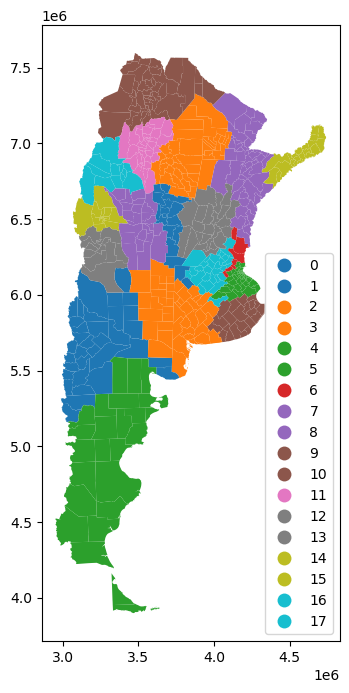

In [64]:
geo_prop.plot(sc.y_pred, figsize = (10,8), categorical = True,legend = True,legend_kwds = {'loc':'lower right'})

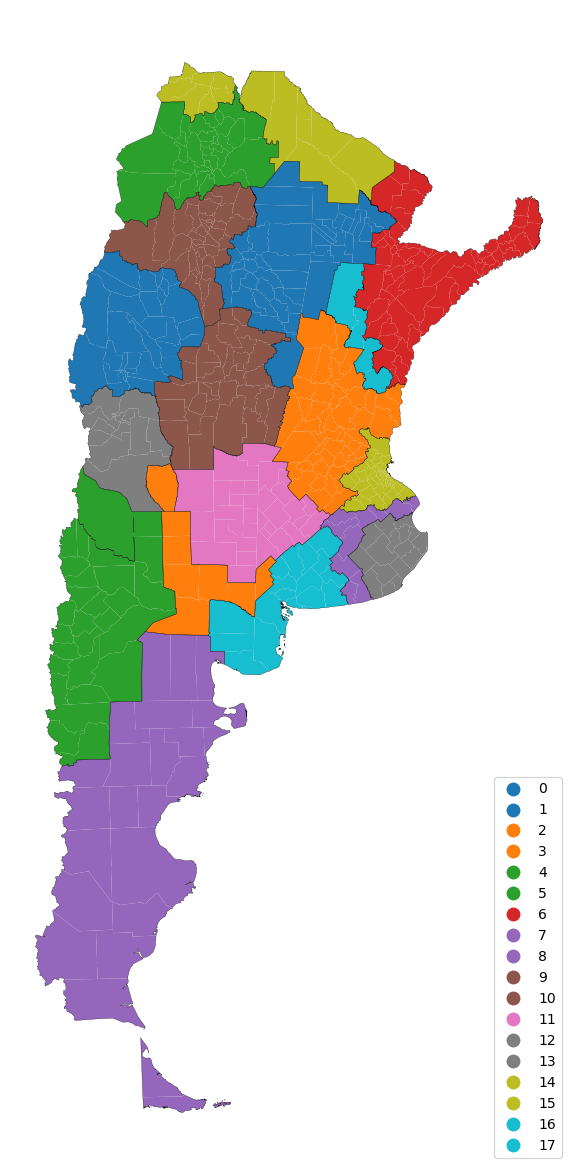

In [52]:
geo_prop
geos = []

for i in np.unique(sc.y_pred):
    g = geo_prop.geometry[sc.y_pred == i].union_all()
    geos.append(g)

geos = gpd.GeoSeries(geos)
base = geos.boundary.plot(figsize = (10,15), color = 'black', edgecolor = 'black', linewidth = 0.2)
graf = geo_prop.plot(sc.y_pred, figsize = (10,8), categorical = True,legend = True,legend_kwds = {'loc':'lower right'}, ax = base)

graf.set_axis_off()

Evaluación de los clusters formados con SDEC

In [53]:
loss = sc.autoencoder.evaluate([X1, X2], prop_st, verbose=1)
print("Pérdida de reconstrucción (cosine_similarity):", loss)
# Obtener embeddings del encoder
embeddings = sc.encoder.predict([X1, X2])

labels = sc.y_pred  # O el atributo correspondiente
print("Silhouette:", silhouette_score(embeddings, labels))
print("Calinski-Harabasz:", calinski_harabasz_score(embeddings, labels))
print("Davies-Bouldin:", davies_bouldin_score(embeddings, labels))

print(suc.SSD(embeddings, labels))
print(suc.SSD(prop_st, labels))

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: -0.1788 
Pérdida de reconstrucción (cosine_similarity): -0.15160366892814636
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Silhouette: 0.66789854
Calinski-Harabasz: 1048.6047
Davies-Bouldin: 1.1252214790468642
{'TSS': np.float32(71168.88), 'WSS': np.float32(103.472984), 'BSS': np.float32(69306.37), 'RBTSS': np.float32(0.9738296)}
{'TSS': np.float64(19212.678593966702), 'WSS': np.float64(750.8092608366992), 'BSS': np.float64(5698.111898906118), 'RBTSS': np.float64(0.29658081620620447)}


In [54]:
from sklearn.metrics import *

def metricas_intrinsecas(datos, grupos):
    sil = round(silhouette_score(datos,grupos),5)
    cal = round(calinski_harabasz_score(datos,grupos),5)
    dav = round(davies_bouldin_score(datos, grupos),5)
    rdo = pd.DataFrame([sil,cal,dav], index = ['Siluetas', 'Kalinski','Davies'])
    return rdo

In [57]:
r_sc = metricas_intrinsecas(prop, sc.y_pred)

r_sc.columns = ['SDEC']
r_sc

,SDEC
Siluetas,-0.12902
Kalinski,13.82620
Davies,4.41373


Calculando las metricas sobre los autoencoders ahí si arroja buenos resultados SDEC y los otros siguen siendo malos

In [58]:
encoders = sc.encoder.predict([X1,X2])
r_enco_sc = metricas_intrinsecas(encoders, sc.y_pred)
r_enco_sc.columns = ['SDEC']
r_enco_sc



17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,SDEC
Siluetas,0.667900
Kalinski,1048.604736
Davies,1.125220


In [59]:
suc.SSD(prop_st, sc.y_pred)

{'TSS': np.float64(19212.678593966702),
 'WSS': np.float64(750.8092608366992),
 'BSS': np.float64(5698.111898906118),
 'RBTSS': np.float64(0.29658081620620447)}

In [60]:
#pd.DataFrame(np.c_[prop_st, sc.y_pred]).to_csv("resultados/covid_sdec.csv")

In [61]:
pred = sc.autoencoder.predict([X1,X2])
mean_squared_error(prop_st, pred)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


0.9937622494184114

## Interpretación con mapas

In [41]:
def graficar_mapa_clusters(gdf, clusters, geos, percentiles=(5, 95), años = [2015, 2018, 2023], promedio = False):
    """
    Graficar los clusters en un mapa utilizando GeoDataFrame y resultados de clustering.
    
    Args:
        gdf (GeoDataFrame): GeoDataFrame con los datos a graficar.
        sc (object): Objeto con los resultados del clustering.
        geos (GeoSeries): GeoSeries con las geometrías de los clusters.
    """

    valores = gdf.iloc[:,:-1].values.flatten()
    vmin = np.percentile(valores, percentiles[0])
    vmax = np.percentile(valores, percentiles[1])
    escalas_colores = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys']
    escalas_colores = (escalas_colores * ((len(np.unique(sc.y_pred)) // len(escalas_colores)) + 1))[:len(np.unique(sc.y_pred))]

    fig, ax = plt.subplots(1, 3, figsize=(20, 15))
    for idx, año in enumerate(años):
        base = geos.boundary.plot(color='black', edgecolor='black', linewidth=0.8, ax=ax[idx])
        for i in np.unique(clusters):
            gdf_ = gdf[clusters == i].copy()
            gdf_.loc[:,'prom'] = gdf_[año].mean()
            col = 'prom' if promedio else año
            gdf_.plot(col, cmap=escalas_colores[i], ax=base, vmin=vmin, vmax=vmax)
            base.set_title(año)
            base.set_axis_off()
    

In [42]:
geo_prop
geos = []

for i in np.unique(sc.y_pred):
    g = geo_prop.geometry[sc.y_pred == i].union_all()
    geos.append(g)

geos = gpd.GeoSeries(geos)

In [43]:
geo_prop.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', 'geometry'],
      dtype='object')

In [44]:
import pandas as pd

# Crear un rango de fechas desde marzo 2020 hasta julio 2021
date_range = pd.date_range(start='2020-03-01', end='2021-07-01', freq='MS')
# Formatear como 'Month-YYYY' con meses en inglés
index_months = [d.strftime('%B-%Y') for d in date_range]
print(index_months)

['March-2020', 'April-2020', 'May-2020', 'June-2020', 'July-2020', 'August-2020', 'September-2020', 'October-2020', 'November-2020', 'December-2020', 'January-2021', 'February-2021', 'March-2021', 'April-2021', 'May-2021', 'June-2021', 'July-2021']


In [45]:
n_geo = geo_prop.loc[:,:'16']
n_geo.columns = index_months
n_geo = gpd.GeoDataFrame(n_geo, geometry=geo_prop.geometry)
n_geo

,March-2020,April-2020,May-2020,June-2020,July-2020,August-2020,September-2020,October-2020,November-2020,December-2020,January-2021,February-2021,March-2021,April-2021,May-2021,June-2021,July-2021,geometry
0,0.525727,1.131479,17.941613,2.939973,1.182836,0.916872,-0.129864,-0.561046,-0.603093,-0.341544,-0.183079,-0.118417,-0.116110,0.111398,-0.472662,-1.078586,-1.023274,"POLYGON ((4200350.769 6147470.664, 4201101.267..."
1,1.112432,0.013858,0.833253,0.444914,0.223000,0.113989,-0.370758,-0.475127,-0.495764,-0.059310,0.170978,0.194884,0.189440,0.172787,-0.569401,-1.044722,-0.922949,"POLYGON ((4198043.775 6148577.659, 4198111.775..."
2,1.258273,0.169296,1.816551,3.189853,1.439562,1.164108,-0.119313,-0.434174,-0.538868,-0.343796,-0.132386,-0.088092,0.149286,0.448826,-0.255701,-0.931536,-0.978494,"POLYGON ((4198450.276 6145157.669, 4198456.277..."
3,-0.082813,0.262873,4.182255,8.580371,2.486270,1.668335,-0.064495,-0.435356,-0.531509,-0.315170,-0.234155,-0.147688,0.099760,0.489578,-0.194575,-0.896327,-1.014130,"POLYGON ((4201672.77 6142869.179, 4201695.77 6..."
4,0.326956,0.229925,0.706467,1.712132,0.670755,0.630046,-0.167299,-0.455979,-0.545880,-0.297451,-0.121690,0.029780,0.130117,0.307600,-0.368934,-1.001508,-0.906357,"POLYGON ((4196342.782 6145516.166, 4196373.783..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,-0.052570,-0.090964,-0.209211,-0.335597,-0.271708,-0.026741,1.037454,2.501907,1.295136,-0.129385,-0.545533,-0.374756,0.489706,0.528015,-0.170812,0.708458,1.054173,"POLYGON ((3528344.175 7068079.973, 3528726.423..."
521,-0.236998,-0.241914,-0.001967,-0.381938,-0.312088,-0.497583,0.029706,-0.089884,-0.014681,-0.309833,-0.669506,-0.746777,-0.293726,0.534877,-0.115082,0.152969,0.134811,"POLYGON ((3545611.595 7114982.766, 3545704.095..."
522,0.510028,-0.046259,-0.131857,-0.281830,-0.307418,-0.034288,1.361356,2.483968,1.143238,0.215893,0.093525,0.274151,1.585074,0.983671,-0.071764,0.854512,1.633956,"POLYGON ((3574142.728 7037932.61, 3573938.229 ..."
523,0.563717,0.334806,-0.213757,-0.355112,1.230827,4.658920,4.682895,7.539773,3.607164,1.196560,0.828308,0.470526,0.363211,0.328167,-0.467019,-0.886325,0.026290,"POLYGON ((3331409.067 3951568.417, 3330689.068..."


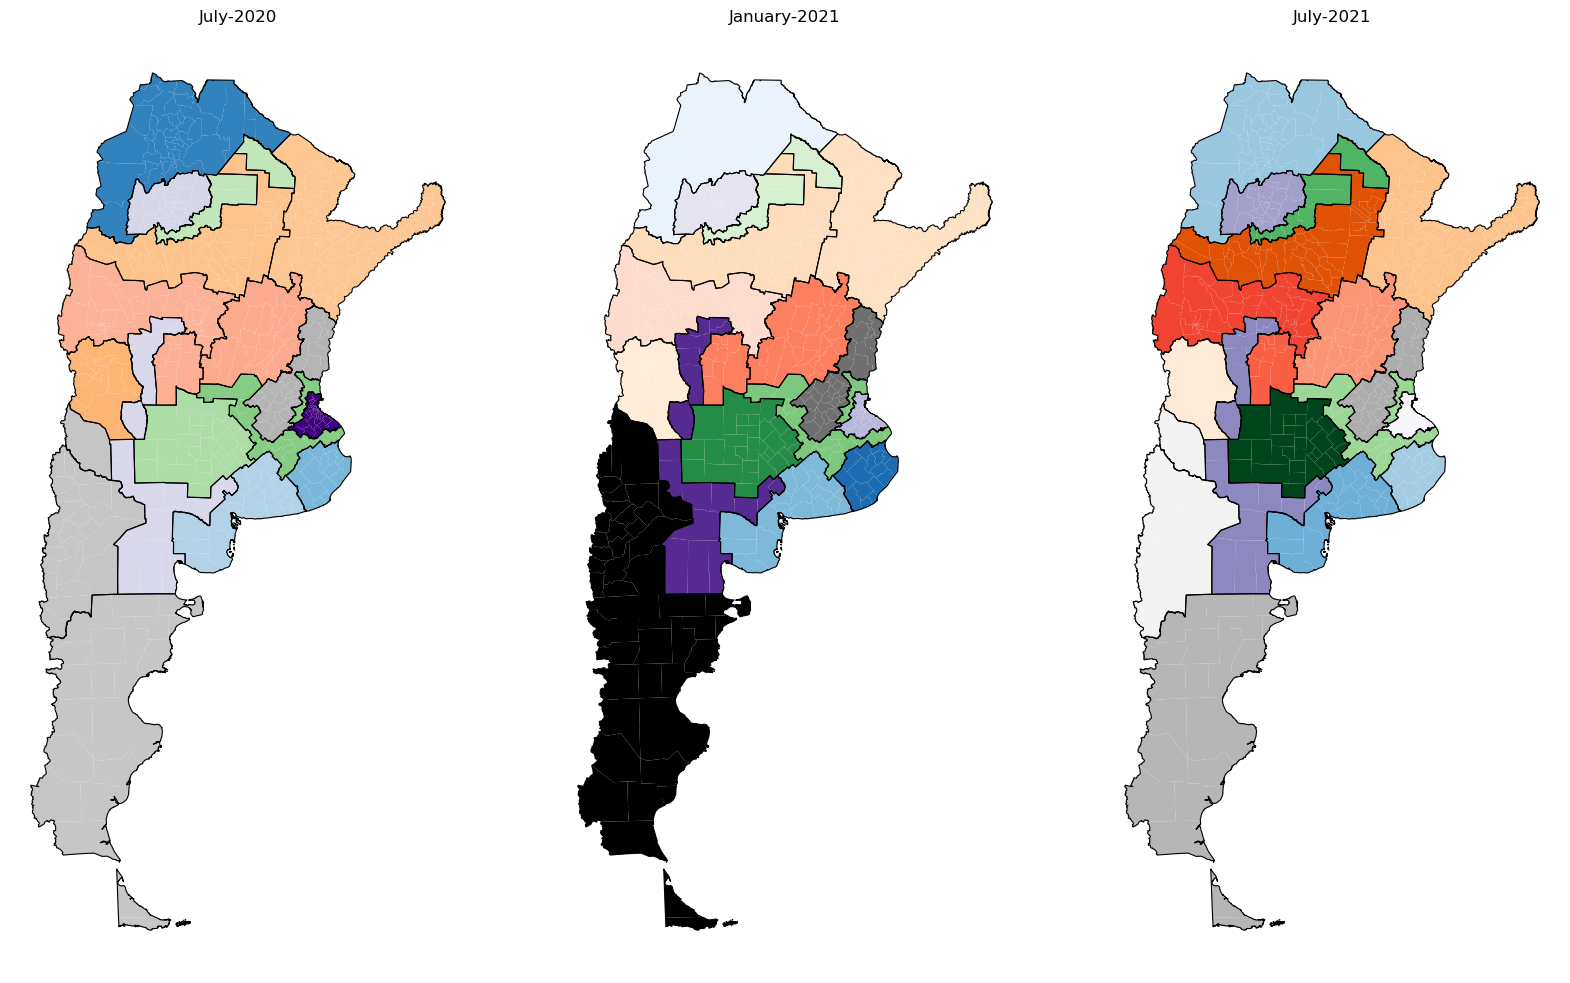

In [46]:
graficar_mapa_clusters(n_geo, sc.y_pred, geos,percentiles =(10,90)
                       , años=[index_months[4], index_months[10], index_months[16]], promedio=True)

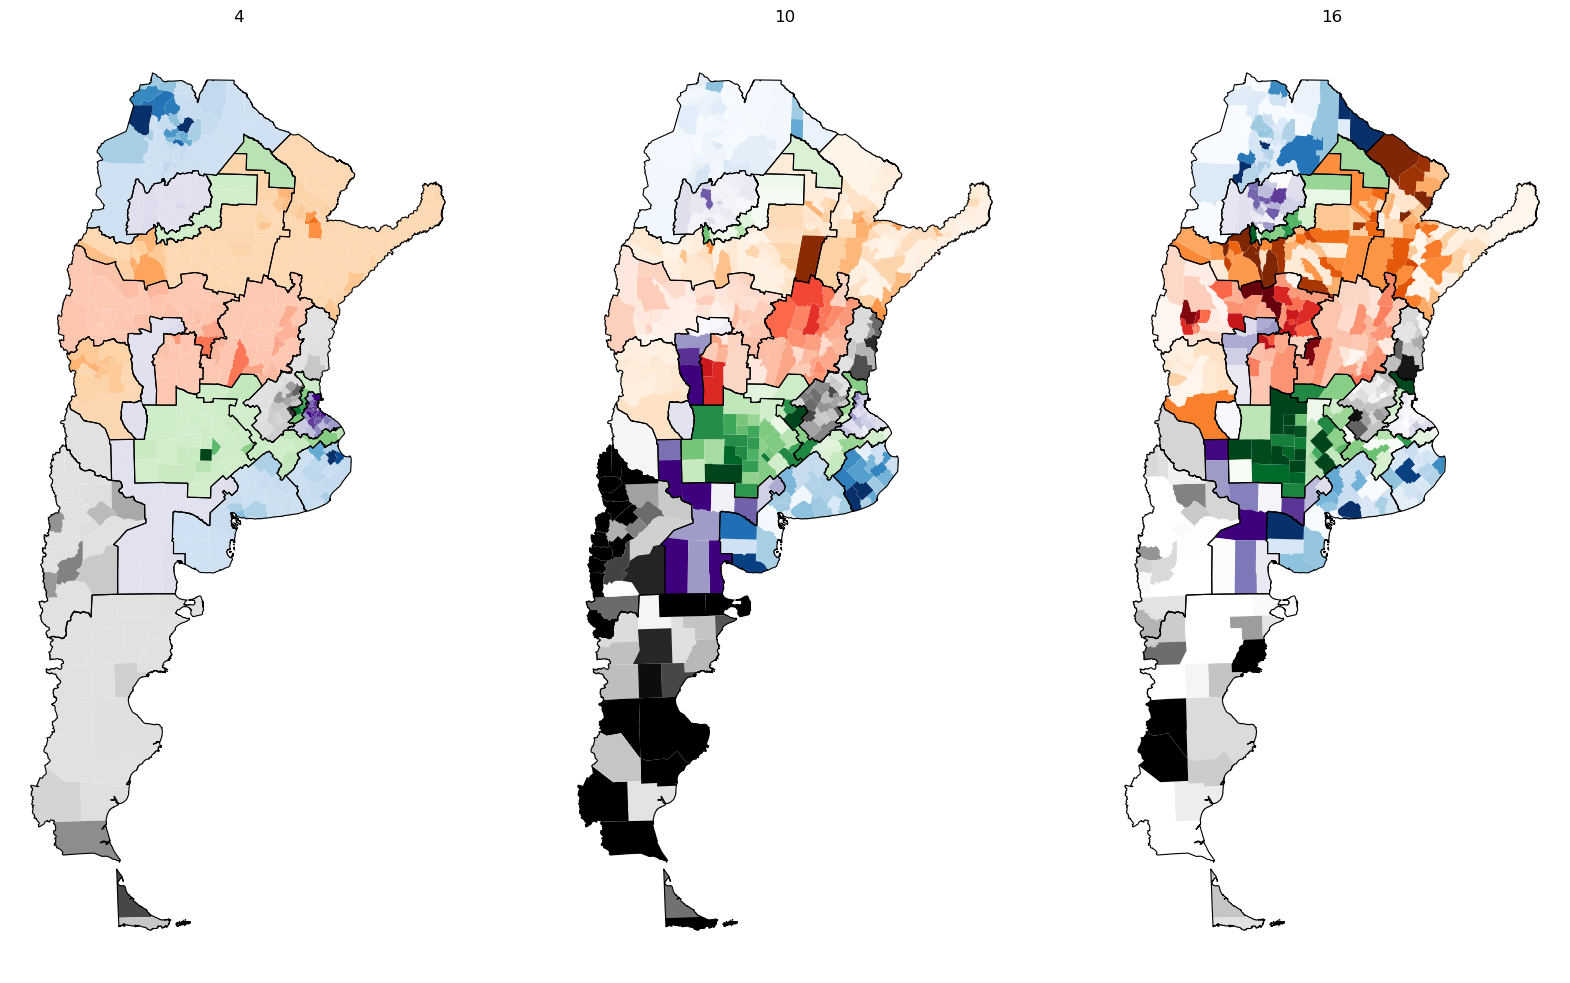

In [47]:
graficar_mapa_clusters(geo_prop, sc.y_pred, geos, años=['4', '10', '16'], promedio=False)